In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch import nn
from src.utils import get_dataset, get_diffusion_schedule_nickname, get_diffusion_weights, get_n_qubits_from_data, set_device, get_path
from src.QDDPM_torch_angel import QDDPMDiffuser
from tqdm import tqdm
import pytorch_optimizer
from functools import partial
from livelossplot import PlotLosses
from opt_einsum import contract
import qutip as qt
from qutip import Bloch
from src.QDDPM_torch_angel import WassDistance
from sklearn.model_selection import train_test_split

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

def ndim_cluster0Gen(n_data, n_qubits, epsilon, rng=None):
    states0 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states0[:, 0] = 1.
    states1 = np.zeros((n_data, 2**n_qubits), dtype=np.complex64)
    states1[:, 1] = 1.

    re_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    im_c = rng.normal(loc=0.0, scale=1.0, size=n_data)
    c = re_c + 1j*im_c
    c = c[:, np.newaxis]
    states = states0 + epsilon*c*states1
    states /= np.linalg.norm(states, axis=1, keepdims=True)
    
    return states

def gen_data(config, diffuser: QDDPMDiffuser, diffusion_weights, t, rng):
    device = config['device']
    size = config['dataset']['maxsize']
    size = size if size is not None else 60000
    name = config['dataset']["name"]
    parts = name.split('_')
    n_qubits = int(parts[1])
    n_features = 2**n_qubits
    initialqstates = ndim_cluster0Gen(size, int(n_qubits), epsilon=0.08, rng=rng)

    # Now diffuse just one timestep.
    states_diffused = torch.zeros((t+1, size, n_features), dtype=torch.complex64, device=device)
    states_diffused[0] = torch.from_numpy(initialqstates).to(device)
    for tt in (range(1, t+1)):
        # states[t] = model.set_diffusionData_t(t, states[0], diffusion_weights[:t], seed=t)
        states_diffused[tt] = diffuser.set_diffusionData_t_single_step(tt, states_diffused[tt-1], diffusion_weights[:tt], seed=tt)
        states_diffused[tt] = states_diffused[tt] / torch.norm(states_diffused[tt], dim=1, keepdim=True) # Avoid numerical errorsdir, filename = get_path(self.config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
    X, y = states_diffused[t].cpu(), states_diffused[t-1].cpu() # The two steps involved in the current timestep t.
    return X, y    

config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './results_MLP',
        'name': 'CLUSTER0_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 1000
    },
    'model': {
        'n_timesteps': 20,
        'diffusion_schedule': {
            'name': 'linear',
            'slope': 6,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}

n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = 2**n_qubits
diffusion_schedule_nickname = get_diffusion_schedule_nickname(config)
n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
get_path_partial = partial(get_path, config, modeltype='MLP', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)

I0000 00:00:1776267030.388028 1310609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776267031.292203 1310609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
/home/angel/miniconda3/envs/dffs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as n

Using device: cpu


In [2]:
class MLP(torch.nn.Module):
    def __init__(self, input_feats, n_hidden_layers, output_feats):
        super().__init__()
        input_dim = 2*input_feats
        output_dim = 2*output_feats
        hidden_dim = 4*input_dim
        layers = []
        for _ in range(n_hidden_layers):
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.ReLU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, output_dim))
        self.mlp = torch.nn.Sequential(*layers)

    def forward(self, x): # x.shape = (batch_size, n_features (complex))
        batch_size = x.shape[0]
        x = torch.view_as_real(x) # (batch_size, n_features, 2)
        x = x.view(batch_size, -1)
        x_output = self.mlp(x)
        x_output = x_output.view(batch_size, -1, 2)
        x_output = torch.view_as_complex(x_output)
        norm = torch.linalg.norm(x_output, dim=1, keepdim=True)
        x_output = x_output / norm
        return x_output
    
def quantum_mean_infidelity(pred, true):
    # pred and true are [n_data, n_features] complex tensors
    inner_product = torch.linalg.vecdot(true, pred, dim=-1) # [n_data]
    fidelity = inner_product.abs().pow(2)
    infidelity = 1 - fidelity
    return infidelity.mean()

def mse(pred, true):
    pred_float = torch.view_as_real(pred)
    true_float = torch.view_as_real(true)
    return torch.nn.functional.mse_loss(pred_float, true_float)

def simple_regularization_term(model, lambd=0.1):
    return lambd * sum(p.pow(2).sum() for p in model.parameters())

def eval(model, x):
    model.eval()
    y = model(x)
    return y

## Trainings

Timestep 20

In [15]:
# Savedir
savedir = Path('results_mlp_pocoapoco/models')

from livelossplot.outputs import MatplotlibPlot
def custom_after_subplot(ax: plt.Axes, group_name: str, x_label: str):
    ax.set_title(group_name)
    ax.set_xlabel(x_label)
    ax.legend(loc='center right')
    ax.set_yscale('log')
outputs = [MatplotlibPlot(after_subplot=custom_after_subplot)]

# Declaramos el modelo
device = torch.device('cpu')
input_feats = 2**n_qubits
output_feats = input_feats
n_hidden_layers = 1
model = MLP(input_feats, n_hidden_layers, output_feats).to(device)#.to(torch.float64)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)
print(model)

148
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
)


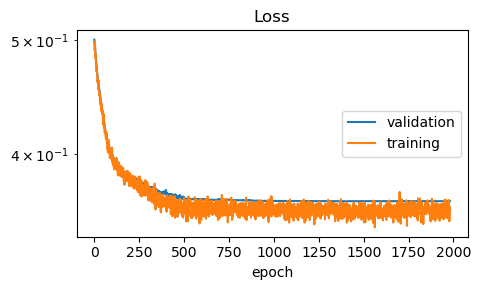

Epoch 2000/2000 Loss: 3.329e-01, LR: 4.0e-07, Last_save: 1562: 100%|██████████| 2000/2000 [01:43<00:00, 19.27it/s]


In [16]:
# Training loop
loss_fn = quantum_mean_infidelity
lr = 4e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
step_size = 500
n_epochs = 4*step_size
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma=0.1)
pbar = tqdm(range(n_epochs))
batch_size = 100
liveloss = PlotLosses(figsize=(9,3), outputs=outputs)

# Select a timestep
TIMESTEP = 20 # 20 --> 19
diffuser = QDDPMDiffuser(config=config, n_data=n_data, n_timesteps=n_timesteps, n_features=n_features, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)

seed = config["seed"]
rng = np.random.default_rng(seed)
X_val, y_val = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
val_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

logs = {}
epochs = []
val_epochs = []
best_loss = float('inf')
last_save_epoch = 0
for epoch in pbar:
    model.train()
    train_loss_epoch = 0

    # Generate new data at each epoch (reproducible)
    X, y = gen_data(config, diffuser, diffusion_weights, TIMESTEP, rng)
    train_dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=False)


    for batch in train_dataloader:
        X, y = batch
        # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        x = model(X)
        loss = loss_fn(x, y)# + simple_regularization_term(model, lambd=1e-1)
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        train_loss_epoch += loss_value
    avg_train_loss_epoch = train_loss_epoch / len(train_dataloader)

    model.eval()
    with torch.no_grad():
        val_loss_epoch = 0
        for batch in val_dataloader:
            X, y = batch
            # X, y = X.to(device).to(torch.complex128), y.to(device).to(torch.complex128)
            X, y = X.to(device), y.to(device)
            x = model(X)
            loss = loss_fn(x, y)
            loss_value = loss
            val_loss_epoch += loss_value
        avg_val_loss_epoch = val_loss_epoch / len(val_dataloader)
        logs['val_loss'] = avg_val_loss_epoch
        val_epochs.append(epoch)

    logs['loss'] = avg_train_loss_epoch
    epochs.append(epoch)
    liveloss.update(logs)
    pbar.set_description(f'Epoch {epoch+1}/{n_epochs} Loss: {loss_value:.3e}, LR: {lr_scheduler.get_last_lr()[0]:.1e}, Last_save: {last_save_epoch}')
    lr_scheduler.step()

    if avg_train_loss_epoch < best_loss:
        best_loss = avg_train_loss_epoch
        last_save_epoch = epoch
        filename = f'bestmodel_pretrained_{TIMESTEP}.pt'
        path = savedir/filename
        savedir.mkdir(parents=True, exist_ok=True)
        torch.save({
                'model_state_dict': model.state_dict(),
                'train_loss_hist': logs['loss'],
                'val_loss_hist': logs['val_loss'],
                'epochs_hist': epochs,
                'val_epochs_hist': val_epochs
                }, path)
    if epoch % 99 == 0:
            liveloss.send()